<a href="https://colab.research.google.com/github/krishnak2004/AMB2108-AIML/blob/main/MODULE_3Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Program 1

#split the dataset to train and test model
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=1/3,random_state=0)

NameError: name 'x' is not defined

In [6]:
# Program 2

#create decision tree classifier object
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(criterion="entropy",max_depth=None,min_samples_split=5,min_samples_leaf=5)

In [7]:
# Program 3

#train model('fit method')
#model=obj.fit(x_train,y_train)
model.fit(x_train,y_train)

NameError: name 'x_train' is not defined

In [ ]:
# Program 4

#predict the testing model
y_pred=model.predict(x_test)
y_pred

In [ ]:
# Program 5

from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

In [8]:
# Program 6

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

NameError: name 'y_test' is not defined

In [ ]:
# Program 7

from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

In [9]:
# Program 8

#visulization
from sklearn.tree import plot_tree
fn=['sepal length(cm)','sepal width(cm)','petal length(cm)','petal width(cm)']
cn=['setosa','versicolor','virginica']
fig, axes=plt.subplots(nrows=1,ncols=1,figsize=(4,4),dpi=300)
plot_tree(model,feature_names=fn,class_names=cn,filled=True)


plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Program 9

!pip install tensorflow

In [10]:
# Program 10

import tensorflow as tf
mnist=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Program 11

print('train images shape',train_images.shape)
print('train labels shape',train_labels.shape)
print('test images shape',test_images.shape)
print('test labels shape',test_labels.shape)

train images shape (60000, 28, 28)
train labels shape (60000,)
test images shape (10000, 28, 28)
test labels shape (10000,)


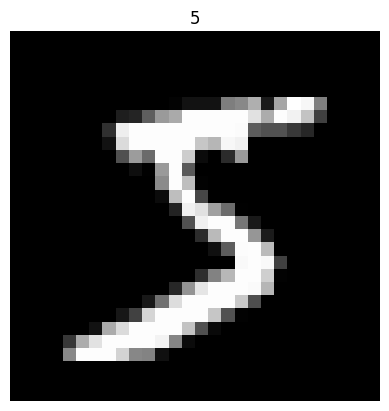

In [12]:
# Program 12

import matplotlib.pyplot as plt
plt.imshow(train_images[0],cmap='grey')
plt.title(train_labels[0])
plt.axis('off')
plt.show()

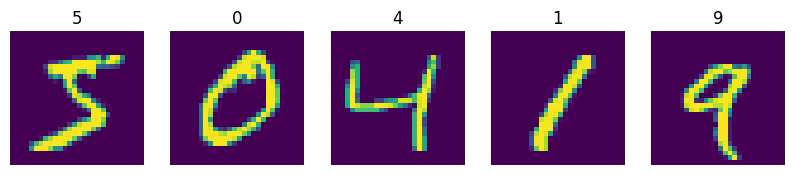

In [13]:
# Program 13

plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(train_images[i])
  plt.title(train_labels[i])
  plt.axis('off')
plt.show()

In [14]:
# Program 14

# step 2 normalize values (0 to 1)
train_images=train_images/255.0
test_images=test_images/255.0

train_images=train_images.reshape(60000,28,28,1)
test_images=test_images.reshape(10000,28,28,1)

In [15]:
# Program 15

from tensorflow.keras  import layers ,models
model= models.Sequential([
    layers.Conv2D(16,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(32,activation='relu'),
    layers.Dense(10,activation='softmax')


])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step
Original Label: 2
Predicted Label: 8


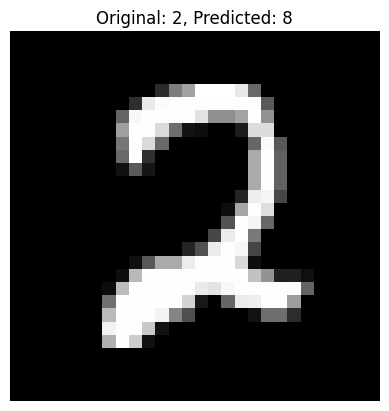

In [16]:
# Program 16

import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = test_labels[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input) # gives probability from 0 to 9
predicted_label = np.argmax(prediction) # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [17]:
# Program 17

# Step 4: Build CNN model

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'), #convolution layer 2
    tf.keras.layers.MaxPooling2D(2,2), #pooling layer 2

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Step 5: Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train model
model.fit(train_images,train_labels, epochs=3) # Changed test_labels to train_labels
#print(model.summary())

# Step 7: Test model
test_loss, test_acc = model.evaluate(test_images, test_labels) # Changed y_test to test_labels
print("Accuracy:", test_acc)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9414 - loss: 0.1873
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9801 - loss: 0.0635
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9853 - loss: 0.0470
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9875 - loss: 0.0352
Accuracy: 0.987500011920929
